<a href="https://colab.research.google.com/github/madanjha/Machine-Learning/blob/main/OLS13thSept2025.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**What is OLS**
OLS is a technique to find the best fit line (hyperplane) in linear regression by minimizing the SSE(sum of squared errror) difference between the actual and predicted data points

OLS = Ordinary Least Square

`actual values - predicted values`

We can also get the negative errors -> To overcome we are going to square the errors and then add.
* We will apply ols which will find the least sum of all possible

###**OLS Cofficient Formula**
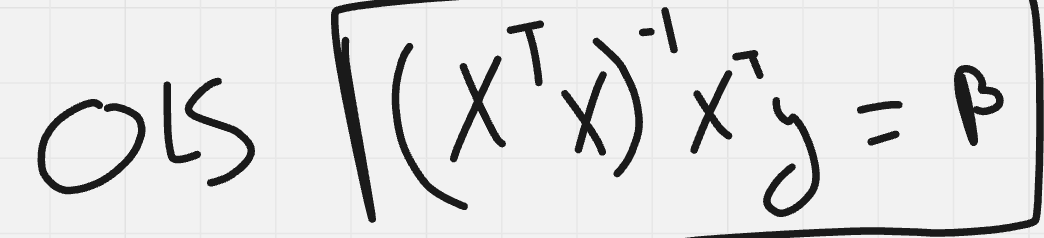

###**Derivation of formula** (Optional)
**Prediction and Errors Calculation**

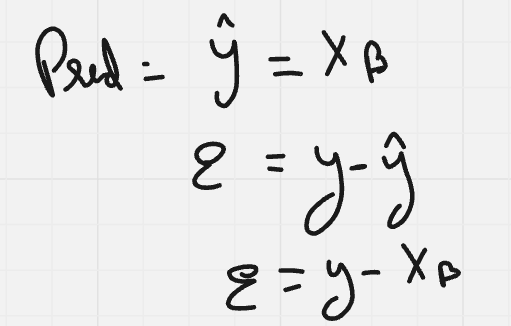

**Expanded the SSE**

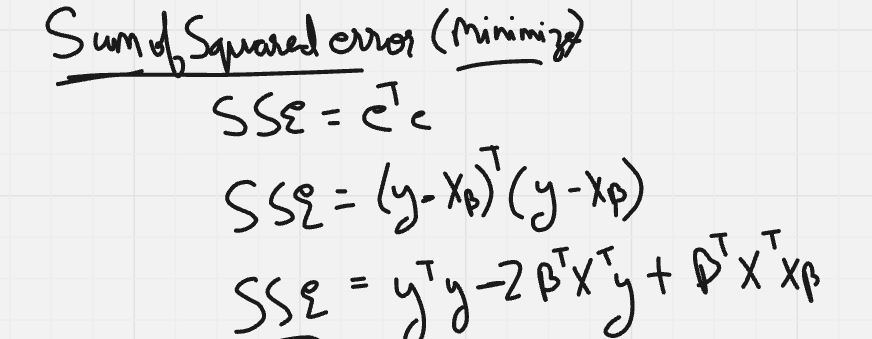

**We did Minimize the step using derivative (Gradient)**

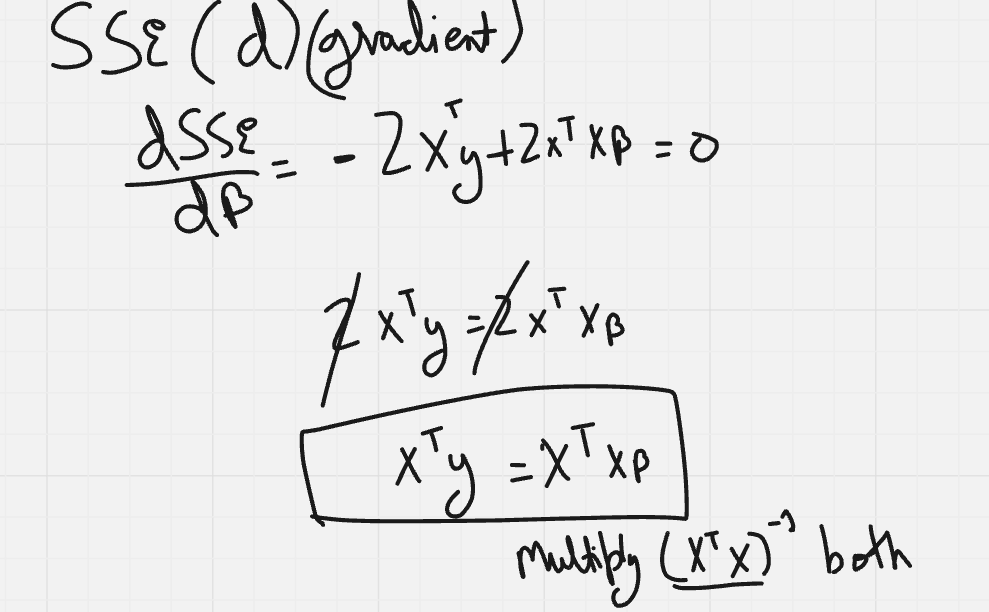

**Finally we will get the equation**

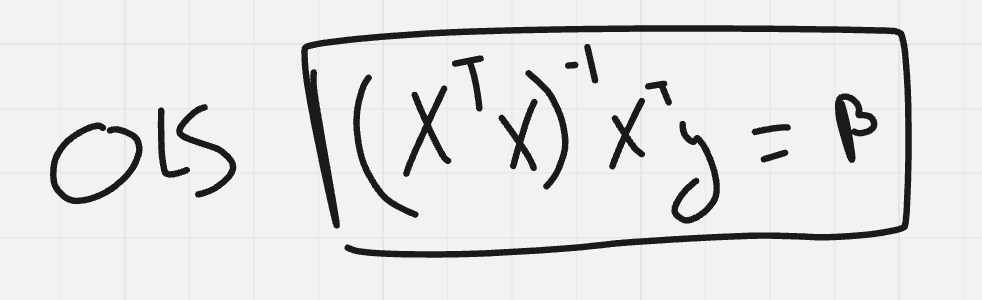

* B0 -> Intercept coff
* B1 -> Slope coff

**Mathematical Example**

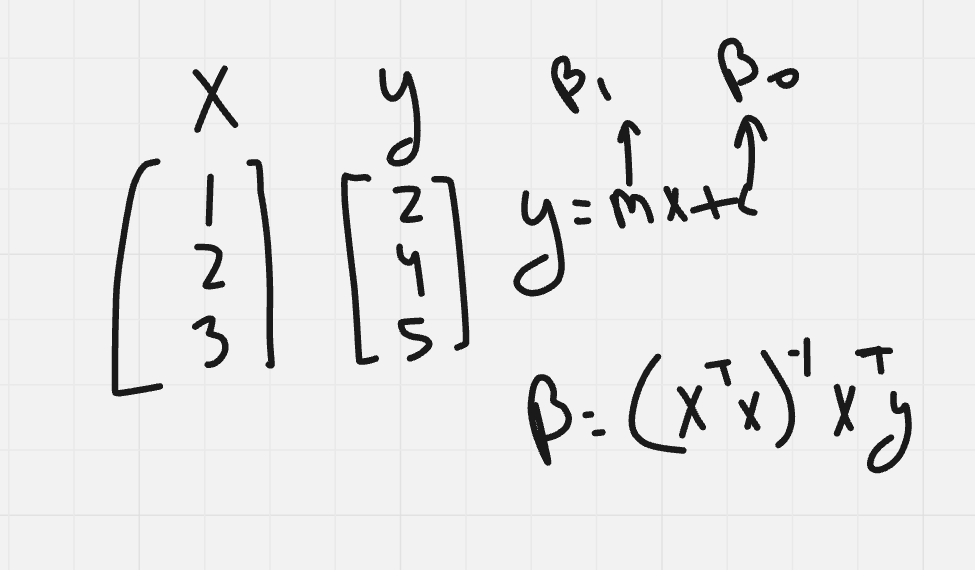

**Initially we found X and X^T where i have added C as 1 for now**
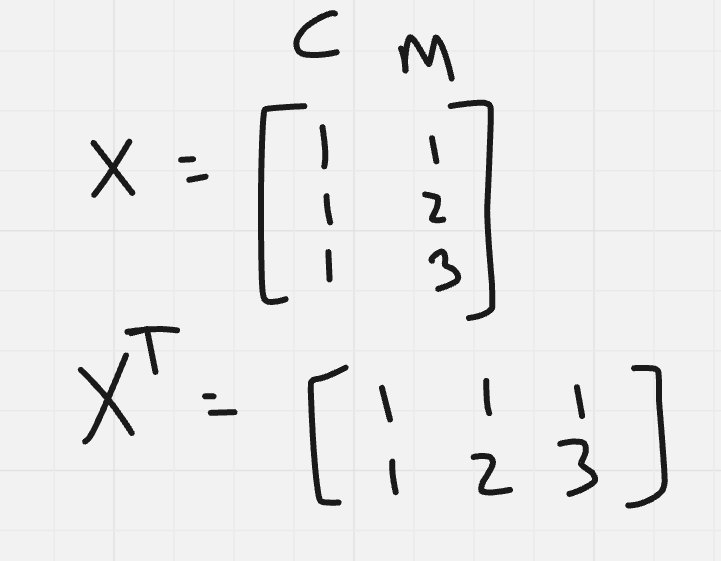

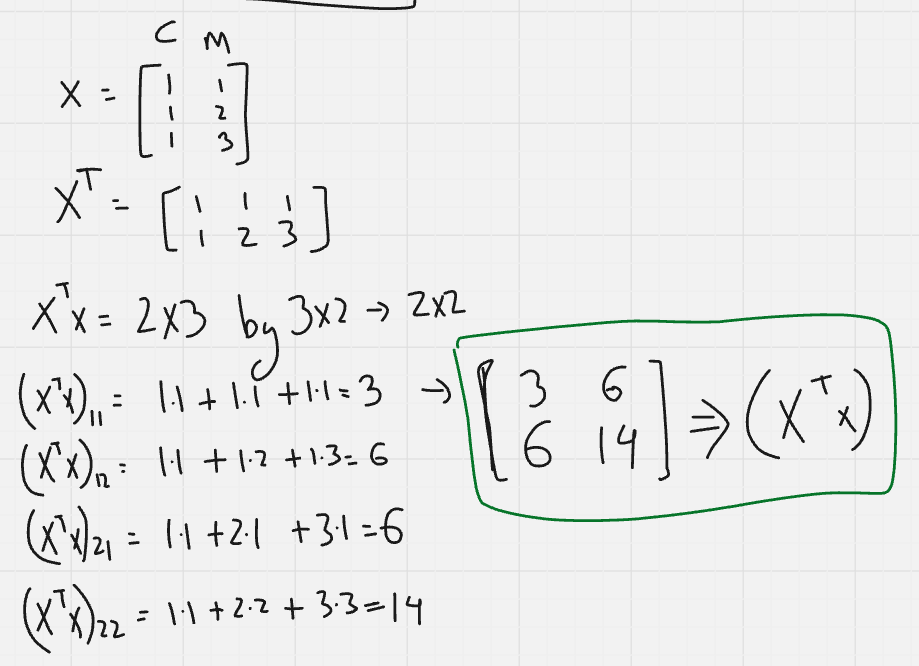

**Now we will find `x^t.Y`**

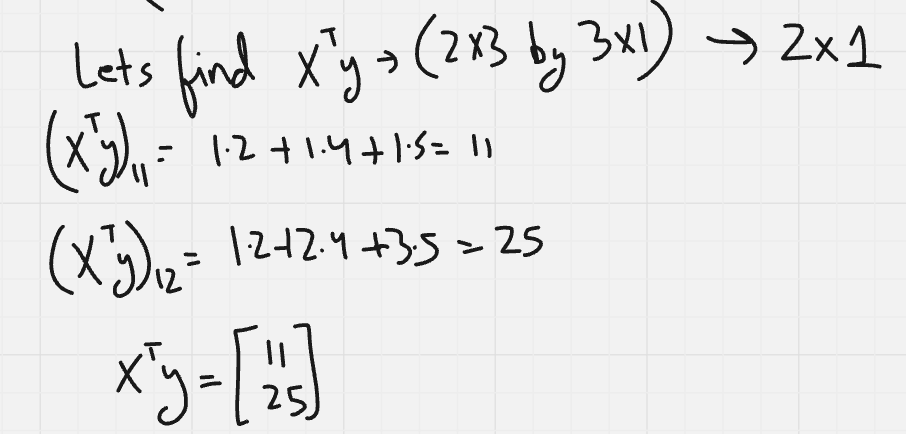

**We find here the inverse of the `X^t.X`, We needed to find discrimnant**

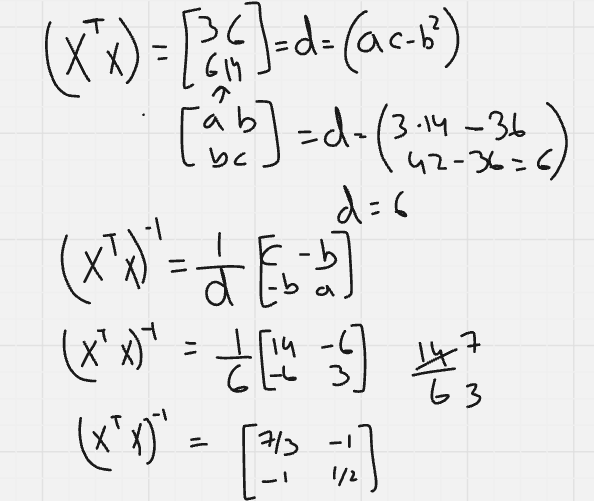

**Merge the both equation**

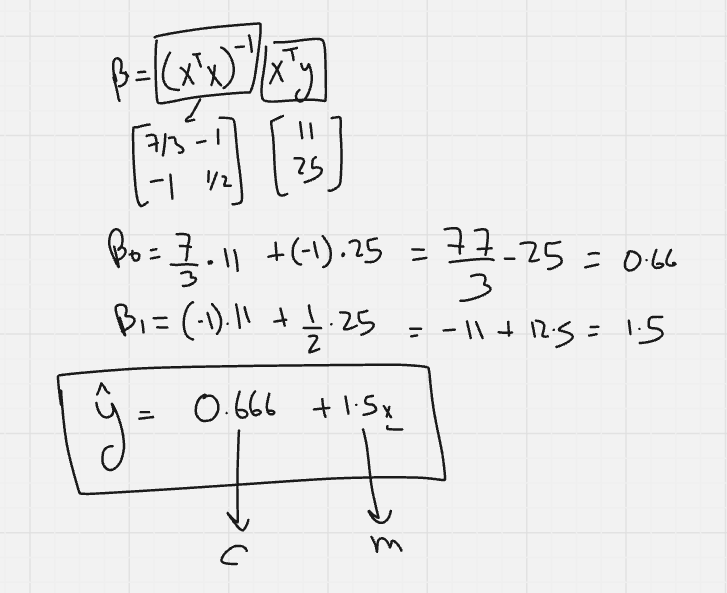

##**Linear Regression with OLS by default**

**Sample Dataset link**: https://drive.google.com/file/d/1BjTFpLOQWd-v-RZ1lr4N3zNjL6smpphZ/view?usp=sharing

**Importing libraries**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('/content/Salary_dataset.csv')

In [ ]:
df.head()

,Unnamed: 0,YearsExperience,Salary
0,0,1.2,39344.0
1,1,1.4,46206.0
2,2,1.6,37732.0
3,3,2.1,43526.0
4,4,2.3,39892.0


In [ ]:
df = df.drop('Unnamed: 0',axis=1)

In [ ]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


**Independent columns**

In [ ]:
x = df['YearsExperience']

**Dependent column**

In [ ]:
y = df['Salary']

In [ ]:
df.shape

(30, 2)

**Let's Split the data into training and testing set**

In [ ]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test =train_test_split(x,y,test_size=0.1,random_state=0)

In [ ]:
x_train

,YearsExperience
10,4.0
26,9.6
24,8.8
27,9.7
11,4.1
17,5.4
22,8.0
5,3.0
16,5.2
8,3.3


In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model1 = LinearRegression()

**To reshape all the values into df**

In [ ]:
x_train = pd.DataFrame(x_train)
y_train = pd.DataFrame(y_train)
x_test = pd.DataFrame(x_test)
y_test = pd.DataFrame(y_test)

**Now, let's fit the data into the model**

In [ ]:
model1.fit(x_train, y_train)

LinearRegression()

In [ ]:
y_pred = model1.predict(x_test)

In [ ]:
y_pred

array([[ 40629.97301142],
       [123153.87216178],
       [ 65012.03412402]])

In [ ]:
y_test

,Salary
2,37732.0
28,122392.0
13,57082.0


**Evalate the model**

In [ ]:
from sklearn.metrics import *

In [ ]:
r2_score(y_test,y_pred)

0.9817404960196033

In [ ]:
mse = mean_squared_error(y_test,y_pred)

In [ ]:
mse

23954712.657997575

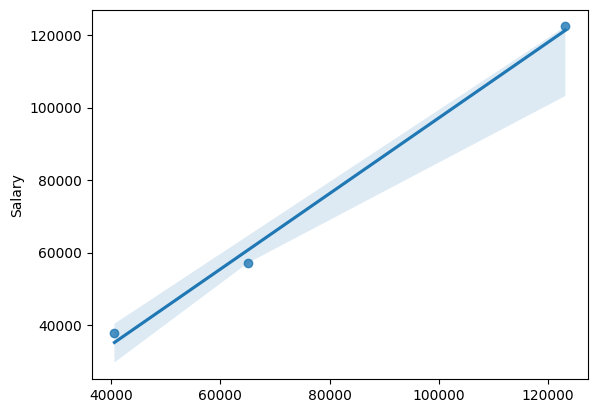

In [ ]:
sns.regplot(x=y_pred, y = y_test)
plt.show()

In [ ]:
model1.intercept_ # intercept

array([25625.62771135])

In [ ]:
model1.coef_ # slope

array([[9377.71581254]])

**Let's Take year of experience form the user and let's check the predicted Salary**

In [ ]:
from warnings import filterwarnings
filterwarnings('ignore')

In [ ]:
userValue = float(input('Enter the year of experience you have: '))
x_test = pd.DataFrame([userValue])

y_pred = model1.predict(x_test)
print(f'Your Salary should be: {y_pred}')

Enter the year of experience you have: 10.5
Your Salary should be: [[124091.64374303]]


**Documentation that for OLS in Linear Regression:** https://www.statsmodels.org/dev/generated/statsmodels.regression.linear_model.OLS.html

##**Linear Regression with OLS Seperatly**

In [ ]:
df

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0
5,3.0,56643.0
6,3.1,60151.0
7,3.3,54446.0
8,3.3,64446.0
9,3.8,57190.0


In [ ]:
x

,YearsExperience
0,1.2
1,1.4
2,1.6
3,2.1
4,2.3
5,3.0
6,3.1
7,3.3
8,3.3
9,3.8


In [ ]:
y

,Salary
0,39344.0
1,46206.0
2,37732.0
3,43526.0
4,39892.0
5,56643.0
6,60151.0
7,54446.0
8,64446.0
9,57190.0


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.1, random_state=0)

In [ ]:
len(x_test)

3

In [ ]:
len(x_train)

27

In [ ]:
x_train = pd.DataFrame(x_train)
x_test = pd.DataFrame(x_test)
y_train = pd.DataFrame(y_train)
y_test = pd.DataFrame(y_test)

**We will add a column of ones for the intercept**

In [ ]:
x_train_ols = np.hstack((np.ones((x_train.shape[0],1)),x_train))

In [ ]:
x_train_ols

array([[ 1. ,  4. ],
       [ 1. ,  9.6],
       [ 1. ,  8.8],
       [ 1. ,  9.7],
       [ 1. ,  4.1],
       [ 1. ,  5.4],
       [ 1. ,  8. ],
       [ 1. ,  3. ],
       [ 1. ,  5.2],
       [ 1. ,  3.3],
       [ 1. ,  4.6],
       [ 1. ,  8.3],
       [ 1. ,  6.9],
       [ 1. ,  1.4],
       [ 1. , 10.6],
       [ 1. ,  3.1],
       [ 1. ,  2.3],
       [ 1. ,  6. ],
       [ 1. ,  6.1],
       [ 1. ,  3.8],
       [ 1. ,  3.3],
       [ 1. ,  9.1],
       [ 1. ,  2.1],
       [ 1. ,  1.2],
       [ 1. ,  7.2],
       [ 1. ,  5. ],
       [ 1. ,  4.1]])

**We will do the same thing for the x_test**

In [ ]:
x_test_ols = np.hstack((np.ones((x_test.shape[0],1)),x_test))

In [ ]:
x_test_ols

array([[ 1. ,  1.6],
       [ 1. , 10.4],
       [ 1. ,  4.2]])

**Compute the beta (OLS Coffiecients -> B0 and B1)**

In [ ]:
# B = (x'x)^-1 x'y
x_transpose = x_train_ols.T

In [ ]:
x_transpose

array([[ 1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,
         1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,  1. ,
         1. ,  1. ,  1. ,  1. ,  1. ],
       [ 4. ,  9.6,  8.8,  9.7,  4.1,  5.4,  8. ,  3. ,  5.2,  3.3,  4.6,
         8.3,  6.9,  1.4, 10.6,  3.1,  2.3,  6. ,  6.1,  3.8,  3.3,  9.1,
         2.1,  1.2,  7.2,  5. ,  4.1]])

In [ ]:
xTransx = x_transpose @ x_train_ols

In [ ]:
xTransx # (x'x)

array([[ 27.  , 146.2 ],
       [146.2 , 984.32]])

**Now let's fint the inverse of xTransx so that we can multiply it with my x'y**

In [ ]:
inv = np.linalg.inv(xTransx)

In [ ]:
inv # (X'X)^-1

array([[ 0.18921226, -0.02810349],
       [-0.02810349,  0.00519011]])

**Now let's find the `x'y`**

In [ ]:
xTransY = x_transpose @ y_train

In [ ]:
xTransY # x'y

,Salary
0,2062914.0
1,12977140.0


In [ ]:
beta = inv @ xTransY

In [ ]:
beta

,Salary
0,25625.627711
1,9377.715813


In [ ]:
model1.intercept_ # this is my b0

array([25625.62771135])

In [ ]:
model1.coef_ # this is my b1

array([[9377.71581254]])

In [ ]:
y_pred_ols = x_test_ols @ beta

In [ ]:
y_pred_ols

,Salary
0,40629.973011
1,123153.872162
2,65012.034124


In [ ]:
r2_score(y_test,y_pred_ols)

0.9817404960196028

In [ ]:
mean_squared_error(y_test,y_pred_ols)

23954712.65799819

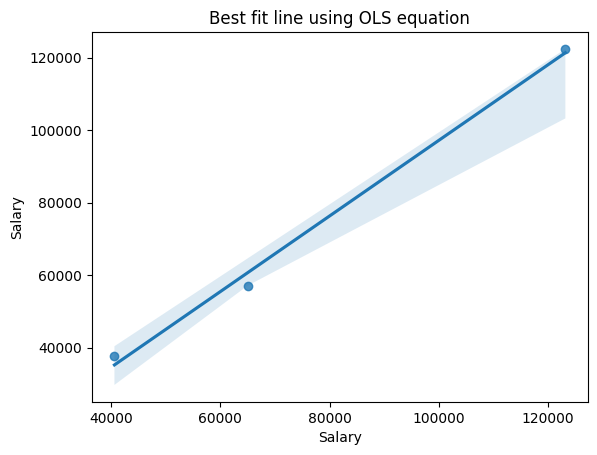

In [ ]:
sns.regplot(x=y_pred_ols, y = y_test)
plt.title('Best fit line using OLS equation')
plt.show()

In [ ]:
df.head()

,YearsExperience,Salary
0,1.2,39344.0
1,1.4,46206.0
2,1.6,37732.0
3,2.1,43526.0
4,2.3,39892.0


###**Observing the difference**
* **Coefficients and intercept:** The values should match closely because the library's linear Regression class internally uses OLS to calculate coffiecients.
* Mean Square Error: Both models should yield similar prediction errors, showing that OLS is the underlying mechanism in both approaches

##**Apply the OLS concept in Multiple Linear Regression**
1. Create a model without using ols seperatly
2. Create a model by using OLS Seperatly
3. Compare their scores

In [ ]:
from sklearn.datasets import fetch_california_housing

In [ ]:
data = fetch_california_housing(as_frame=True)
data

{'data':        MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
 0      8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
 1      8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
 2      7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
 3      5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
 4      3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   
 ...       ...       ...       ...        ...         ...       ...       ...   
 20635  1.5603      25.0  5.045455   1.133333       845.0  2.560606     39.48   
 20636  2.5568      18.0  6.114035   1.315789       356.0  3.122807     39.49   
 20637  1.7000      17.0  5.205543   1.120092      1007.0  2.325635     39.43   
 20638  1.8672      18.0  5.329513   1.171920       741.0  2.123209     39.43   
 20639  2.3886      16.0  5.254717   1.162264      1387.0  2.616981     39.37   
 
        Longitude 

In [ ]:
df = data.frame

In [ ]:
df

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
...,...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09,0.781
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21,0.771
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22,0.923
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32,0.847


**Seperate predictor (X) and Target (Y)**

In [ ]:
x = df.drop(columns='MedHouseVal',axis=1)
y = df['MedHouseVal']

In [ ]:
x

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...
20635,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


In [ ]:
y

,MedHouseVal
0,4.526
1,3.585
2,3.521
3,3.413
4,3.422
...,...
20635,0.781
20636,0.771
20637,0.923
20638,0.847


In [ ]:
a = df.shape
print(f'Rows : {a[0]} and Columns: {a[1]}')

Rows : 20640 and Columns: 9


In [ ]:
df.isnull().sum()

,0
MedInc,0
HouseAge,0
AveRooms,0
AveBedrms,0
Population,0
AveOccup,0
Latitude,0
Longitude,0
MedHouseVal,0


**Building with linear Regression**

In [ ]:
lmodel = LinearRegression()

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
lmodel.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred = lmodel.predict(x_test)

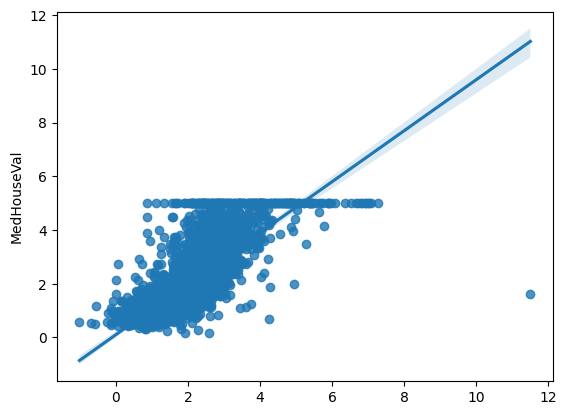

In [ ]:
sns.regplot(x = y_pred,y=y_test)
plt.show()

**Now we will use OLS using a library that is statsmodel -> OLS**

In [ ]:
import statsmodels.api as sm

In [ ]:
x_with_const = sm.add_constant(x) # This is built in method to add constants as 1

In [ ]:
x_with_const

,const,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
0,1.0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23
1,1.0,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22
2,1.0,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24
3,1.0,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25
4,1.0,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25
...,...,...,...,...,...,...,...,...,...
20635,1.0,1.5603,25.0,5.045455,1.133333,845.0,2.560606,39.48,-121.09
20636,1.0,2.5568,18.0,6.114035,1.315789,356.0,3.122807,39.49,-121.21
20637,1.0,1.7000,17.0,5.205543,1.120092,1007.0,2.325635,39.43,-121.22
20638,1.0,1.8672,18.0,5.329513,1.171920,741.0,2.123209,39.43,-121.32


`1. Manual OLS using matrix formula`

In [ ]:
xTx = x_with_const.T @ x_with_const
xTx

,const,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude
const,2.064000e+04,7.989065e+04,5.911190e+05,1.120546e+05,2.263538e+04,2.942184e+07,6.337832e+04,7.354416e+05,-2.467919e+06
MedInc,7.989065e+04,3.837232e+05,2.229286e+06,4.654395e+05,8.646125e+04,1.140969e+08,2.529590e+05,2.839968e+06,-9.553694e+06
HouseAge,5.911190e+05,2.229286e+06,2.019848e+07,3.110677e+06,6.386948e+05,7.554829e+08,1.850710e+06,2.106887e+07,-7.073623e+07
AveRooms,1.120546e+05,4.654395e+05,3.110677e+06,7.346865e+05,1.433999e+05,1.555552e+08,3.415074e+05,4.004316e+06,-1.340115e+07
AveBedrms,2.263538e+04,8.646125e+04,6.386948e+05,1.433999e+05,2.945900e+04,3.153295e+07,6.887751e+04,8.079972e+05,-2.706244e+06
Population,2.942184e+07,1.140969e+08,7.554829e+08,1.555552e+08,3.153295e+07,6.840906e+10,1.073036e+08,1.042924e+09,-3.513289e+09
AveOccup,6.337832e+04,2.529590e+05,1.850710e+06,3.415074e+05,6.887751e+04,1.073036e+08,2.420942e+06,2.259371e+06,-7.577064e+06
Latitude,7.354416e+05,2.839968e+06,2.106887e+07,4.004316e+06,8.079972e+05,1.042924e+09,2.259371e+06,2.629932e+07,-8.801821e+07
Longitude,-2.467919e+06,-9.553694e+06,-7.073623e+07,-1.340115e+07,-2.706244e+06,-3.513289e+09,-7.577064e+06,-8.801821e+07,2.951712e+08


In [ ]:
xTx_inv = np.linalg.inv(xTx)
xTx_inv

array([[ 8.27646497e-01,  1.72111659e-03,  1.39248271e-04,
        -1.68491975e-03,  4.92962578e-03,  2.63665775e-07,
        -2.04491812e-05,  8.00648242e-03,  9.36780455e-03],
       [ 1.72111659e-03,  3.35776643e-05,  3.65028767e-07,
        -3.50988241e-05,  1.55755170e-04,  7.18605547e-10,
        -1.45570626e-07,  2.38464851e-05,  2.25146684e-05],
       [ 1.39248271e-04,  3.65028767e-07,  3.79688224e-07,
         2.22783315e-07, -5.05285320e-07,  1.29426165e-09,
        -1.86765272e-08,  1.58195914e-06,  1.75919435e-06],
       [-1.68491975e-03, -3.50988241e-05,  2.22783315e-07,
         6.60331868e-05, -2.90878937e-04,  2.03275495e-09,
         1.18816210e-07, -2.54600244e-05, -2.24038897e-05],
       [ 4.92962578e-03,  1.55755170e-04, -5.05285320e-07,
        -2.90878937e-04,  1.50905625e-03, -1.76798366e-09,
        -5.00377161e-07,  8.63659107e-05,  7.24858859e-05],
       [ 2.63665775e-07,  7.18605547e-10,  1.29426165e-09,
         2.03275495e-09, -1.76798366e-09,  4.299856

In [ ]:
xTy = x_with_const.T @ y
xTy

,0
const,4.269504e+04
MedInc,1.963919e+05
HouseAge,1.254424e+06
AveRooms,2.407451e+05
AveBedrms,4.629549e+04
Population,6.019595e+07
AveOccup,1.252301e+05
Latitude,1.513970e+06
Longitude,-5.107227e+06


In [ ]:
betaHat = xTx_inv @ xTy

In [ ]:
print('Manual OLS Cofficients {B}: ')
print(betaHat)

Manual OLS Cofficients {B}: 
[-3.69419202e+01  4.36693293e-01  9.43577803e-03 -1.07322041e-01
  6.45065694e-01 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01
 -4.34513755e-01]


In [ ]:
x_test_withConst = sm.add_constant(x_test)

In [ ]:
yHat = x_test_withConst @ betaHat

In [ ]:
yHat

,0
20046,0.736336
3024,1.761255
15663,2.672430
20484,2.843657
9814,2.617310
...,...
15362,2.018378
16623,2.254756
18086,4.455095
2144,1.211464


[]

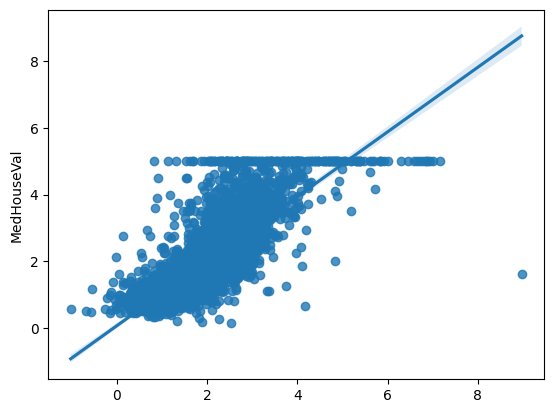

In [ ]:
sns.regplot(x = yHat,y=y_test)
plt.plot()

In [ ]:
len(y_test)

4128

`2. OLS Using Statsmodel (gives detailed summary)`

In [ ]:
model = sm.OLS(y, x_with_const).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:            MedHouseVal   R-squared:                       0.606
Model:                            OLS   Adj. R-squared:                  0.606
Method:                 Least Squares   F-statistic:                     3970.
Date:                Sat, 13 Sep 2025   Prob (F-statistic):               0.00
Time:                        06:59:19   Log-Likelihood:                -22624.
No. Observations:               20640   AIC:                         4.527e+04
Df Residuals:                   20631   BIC:                         4.534e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -36.9419      0.659    -56.067      0.0

**Now you guys try to implement it on other sample datasets**

Load_diabetes dataset

In [ ]:
from sklearn.datasets import load_diabetes
data = load_diabetes(as_frame=True)
df = data.frame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


* Target value -> target (disease progression)
* predictors -> Apart from target

tips data -> seaborn

In [ ]:
df = sns.load_dataset('tips')
df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


* Target: tip
* predictors: total_bill, sex, smoker, day